# **1. Perkenalan Dataset**

Dataset yang digunakan adalah **Telco Customer Churn** dari Kaggle.

Dataset ini berisi informasi pelanggan perusahaan telekomunikasi beserta status churn (berhenti berlangganan).

- **Sumber**: [Kaggle — Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)
- **Jumlah baris**: 7,043
- **Jumlah kolom**: 21
- **Target**: `Churn` (Yes/No) — prediksi apakah pelanggan akan berhenti

Tujuan eksperimen: memahami karakteristik data, melakukan preprocessing, dan menyiapkan data untuk pelatihan model machine learning.

# **2. Import Library**

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder

# Configure visualization style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

# **3. Memuat Dataset**

In [2]:
# Load dataset from CSV file
df = pd.read_csv("../telco_churn_raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Display basic information
print(f"Dataset shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Dataset shape: (7043, 21)
Number of rows: 7043
Number of columns: 21


In [3]:
# Display first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Check data types and missing values
print("Data types:")
print(df.dtypes)
print(f"\nMissing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
Paperl

In [5]:
# Check unique value counts for each column
print("Unique values per column:")
for col in df.columns:
    print(f"  {col}: {df[col].nunique()}")

Unique values per column:
  customerID: 7043
  gender: 2
  SeniorCitizen: 2
  Partner: 2
  Dependents: 2
  tenure: 73
  PhoneService: 2
  MultipleLines: 3
  InternetService: 3
  OnlineSecurity: 3
  OnlineBackup: 3
  DeviceProtection: 3
  TechSupport: 3
  StreamingTV: 3
  StreamingMovies: 3
  Contract: 3
  PaperlessBilling: 2
  PaymentMethod: 4
  MonthlyCharges: 1585
  TotalCharges: 6531
  Churn: 2


# **4. Exploratory Data Analysis (EDA)**

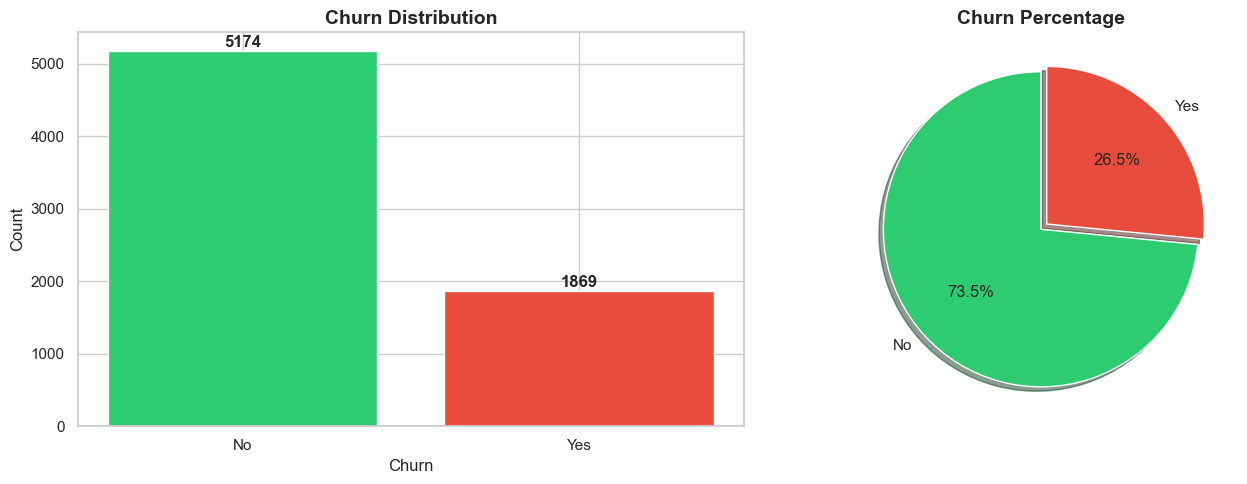


Class distribution:
  No (not churned):  5174 (73.46%)
  Yes (churned):     1869 (26.54%)

[INFO] Dataset mengalami class imbalance (27:73). Perlu stratified split.


In [6]:
# --- Target variable distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
colors = ["#2ecc71", "#e74c3c"]
ax = axes[0]
counts = df["Churn"].value_counts()
bars = ax.bar(counts.index, counts.values, color=colors)
ax.set_title("Churn Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Churn")
ax.set_ylabel("Count")
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f"{count}", ha="center", fontweight="bold")

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
            colors=colors, explode=(0, 0.05), shadow=True, startangle=90)
axes[1].set_title("Churn Percentage", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

print(f"\nClass distribution:")
print(f"  No (not churned):  {counts['No']} ({counts['No']/len(df)*100:.2f}%)")
print(f"  Yes (churned):     {counts['Yes']} ({counts['Yes']/len(df)*100:.2f}%)")
print(f"\n[INFO] Dataset mengalami class imbalance (27:73). Perlu stratified split.")

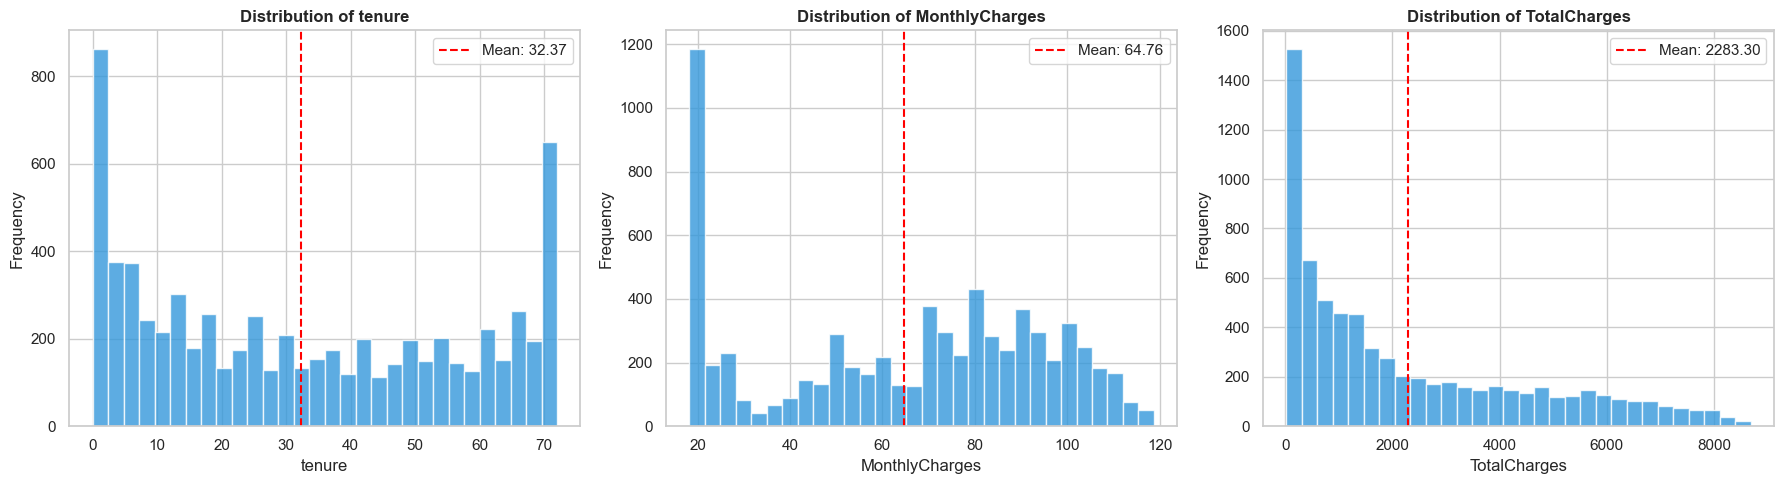

In [7]:
# --- Numeric features distribution ---
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    data = pd.to_numeric(df[col], errors="coerce")
    ax.hist(data.dropna(), bins=30, color="#3498db", edgecolor="white", alpha=0.8)
    ax.set_title(f"Distribution of {col}", fontsize=12, fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax.axvline(data.mean(), color="red", linestyle="dashed", linewidth=1.5, label=f"Mean: {data.mean():.2f}")
    ax.legend()

plt.tight_layout()
plt.show()

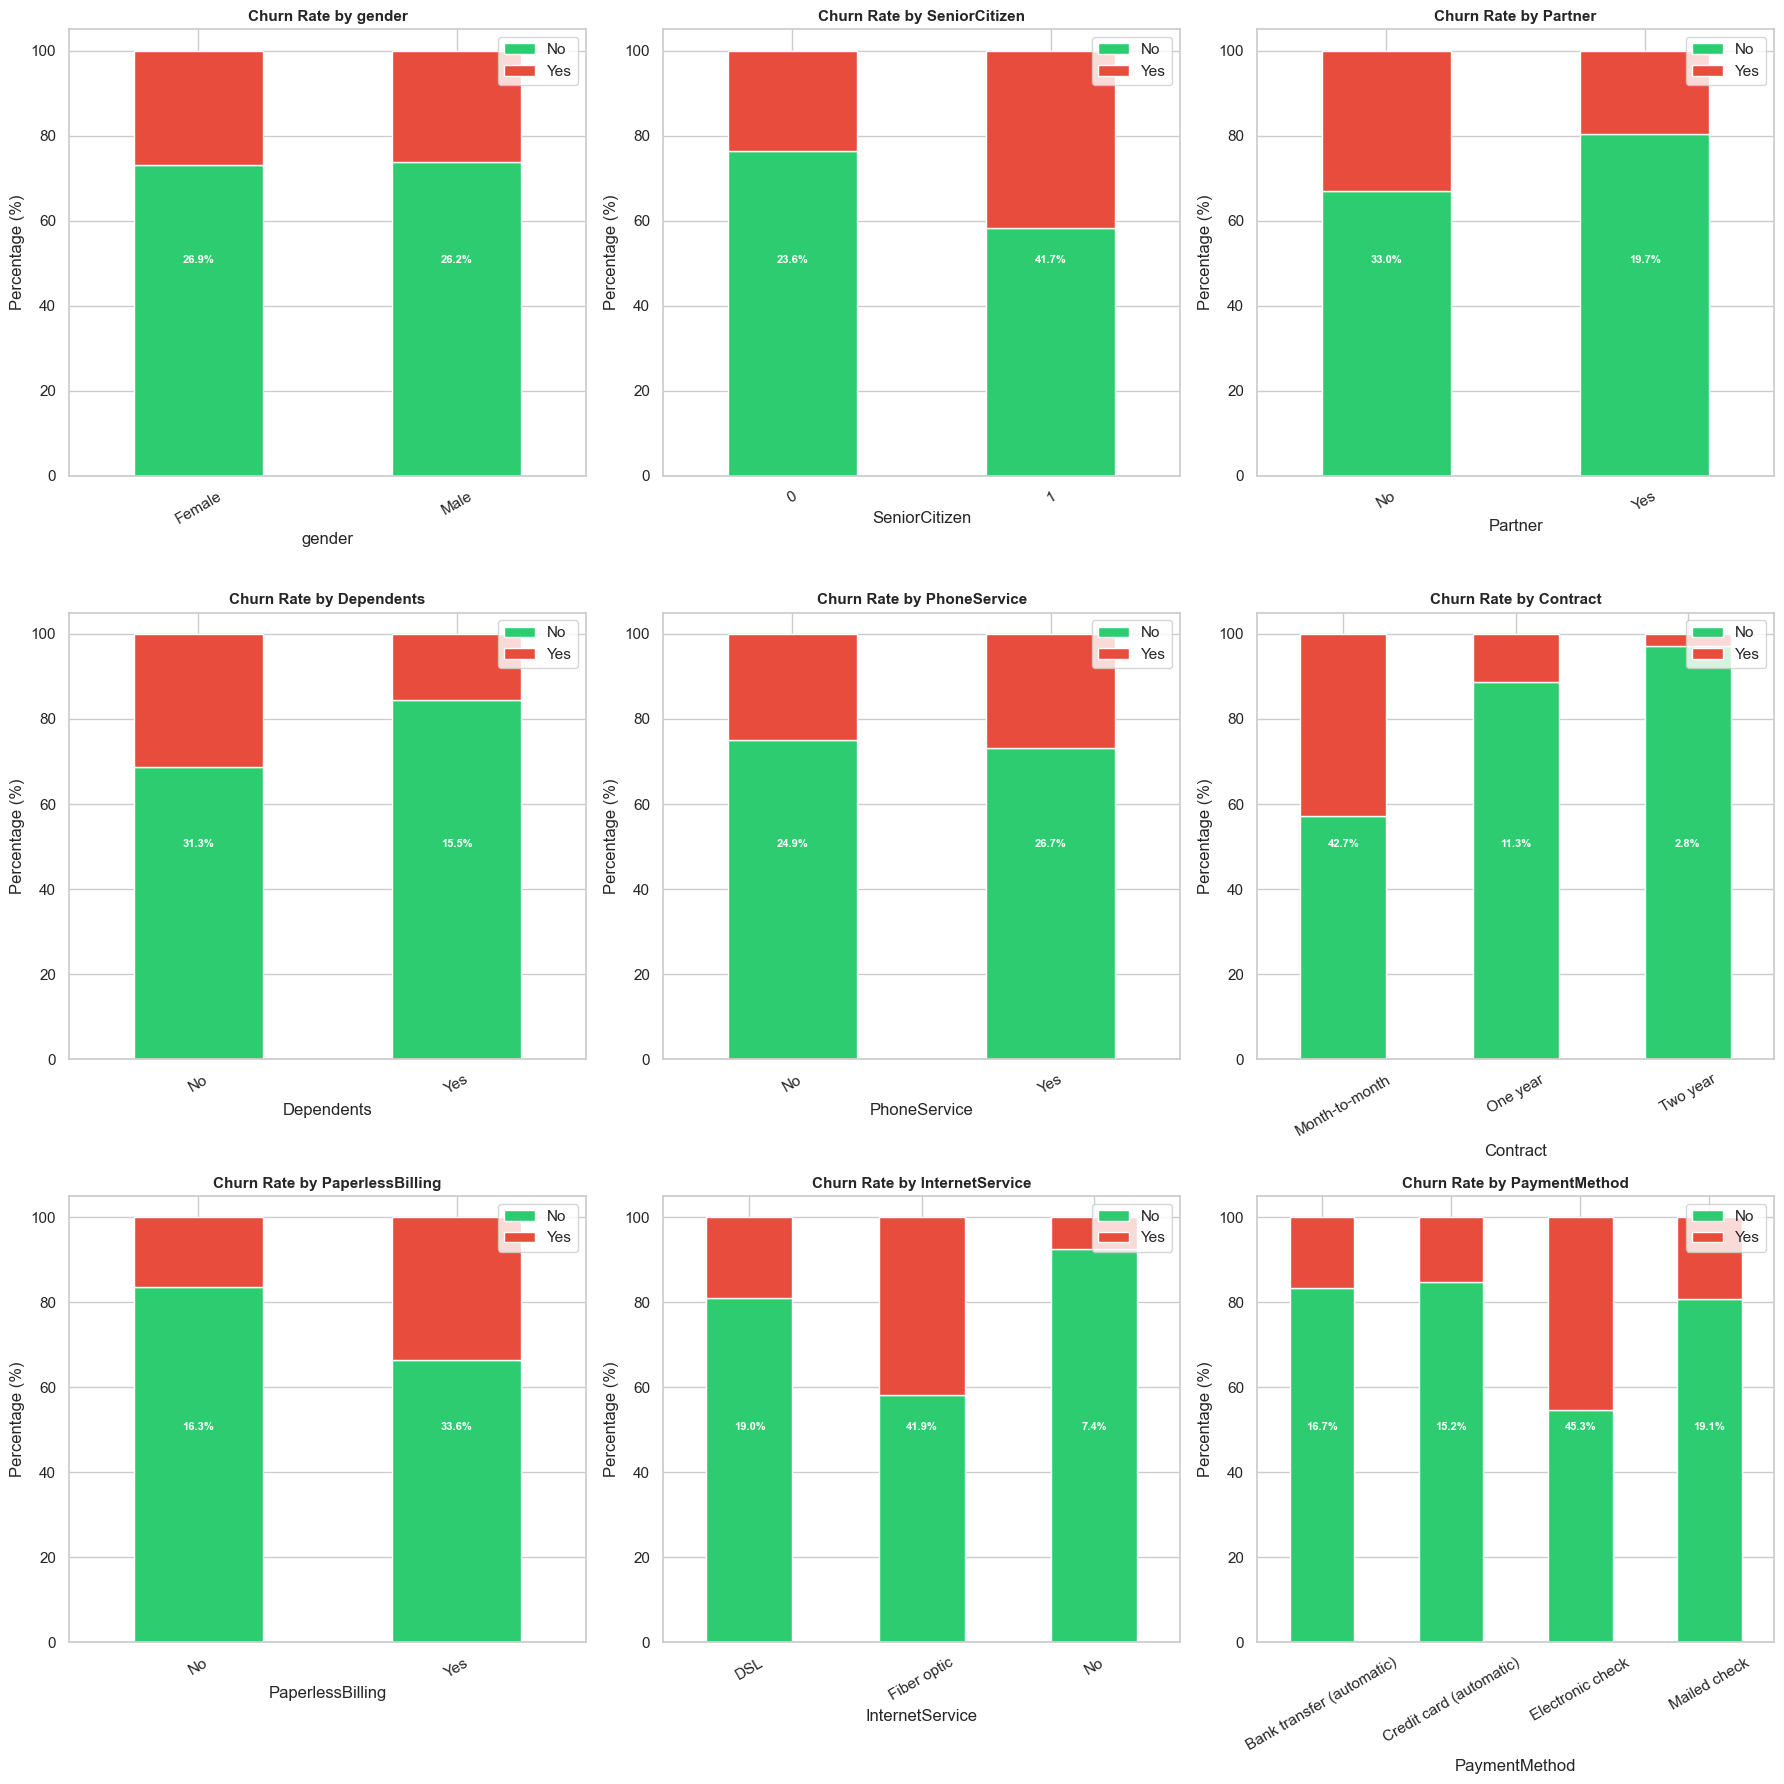

In [8]:
# --- Churn rate by categorical features ---
cat_cols_to_plot = ["gender", "SeniorCitizen", "Partner", "Dependents",
                    "PhoneService", "Contract", "PaperlessBilling",
                    "InternetService", "PaymentMethod"]

fig, axes = plt.subplots(3, 3, figsize=(18, 18))
axes = axes.flatten()

for i, col in enumerate(cat_cols_to_plot):
    ax = axes[i]
    churn_rate = df.groupby(col)["Churn"].value_counts(normalize=True).unstack() * 100
    churn_rate.plot(kind="bar", stacked=True, ax=ax, color=["#2ecc71", "#e74c3c"])
    ax.set_title(f"Churn Rate by {col}", fontsize=11, fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Percentage (%)")
    ax.legend(["No", "Yes"], loc="upper right")
    ax.tick_params(axis="x", rotation=30)
    
    # Add percentage labels on the Yes (red) segment
    for j, (_, row) in enumerate(churn_rate.iterrows()):
        if "Yes" in row.index:
            ax.text(j, 50, f"{row['Yes']:.1f}%", ha="center", fontsize=8, fontweight="bold", color="white")

plt.tight_layout()
plt.show()

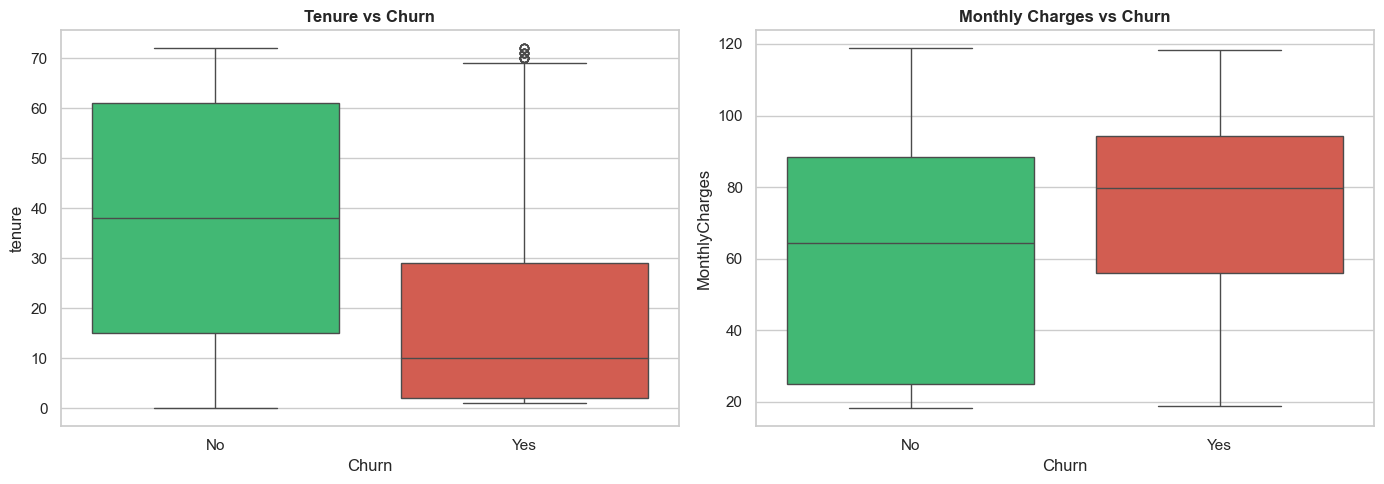

[INFO] Pelanggan dengan tenure rendah cenderung lebih banyak churn.
[INFO] Pelanggan dengan monthly charges tinggi cenderung lebih banyak churn.


In [9]:
# --- Churn by tenure (boxplot) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tenure vs Churn
sns.boxplot(x="Churn", y="tenure", data=df, palette=["#2ecc71", "#e74c3c"], ax=axes[0])
axes[0].set_title("Tenure vs Churn", fontsize=12, fontweight="bold")

# MonthlyCharges vs Churn
sns.boxplot(x="Churn", y="MonthlyCharges", data=df, palette=["#2ecc71", "#e74c3c"], ax=axes[1])
axes[1].set_title("Monthly Charges vs Churn", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

print("[INFO] Pelanggan dengan tenure rendah cenderung lebih banyak churn.")
print("[INFO] Pelanggan dengan monthly charges tinggi cenderung lebih banyak churn.")

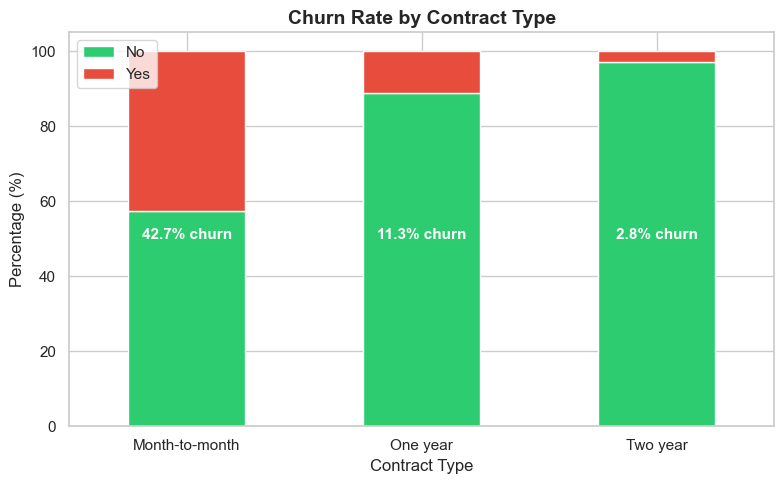

[INFO] Month-to-month contract memiliki churn rate tertinggi.
[INFO] Two year contract memiliki churn rate terendah.


In [10]:
# --- Contract vs Churn (key insight) ---
fig, ax = plt.subplots(figsize=(8, 5))
contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
contract_churn.plot(kind="bar", stacked=True, ax=ax, color=["#2ecc71", "#e74c3c"])
ax.set_title("Churn Rate by Contract Type", fontsize=14, fontweight="bold")
ax.set_xlabel("Contract Type")
ax.set_ylabel("Percentage (%)")
ax.legend(["No", "Yes"])
ax.tick_params(axis="x", rotation=0)

for i, (_, row) in enumerate(contract_churn.iterrows()):
    ax.text(i, 50, f"{row['Yes']:.1f}% churn", ha="center", fontsize=11, fontweight="bold", color="white")

plt.tight_layout()
plt.show()

print("[INFO] Month-to-month contract memiliki churn rate tertinggi.")
print("[INFO] Two year contract memiliki churn rate terendah.")

In [11]:
# --- Statistical summary ---
print("Descriptive statistics (numeric features):")
display(df.describe())

print("\nDescriptive statistics (categorical features):")
display(df.describe(include=["object"]))

Descriptive statistics (numeric features):


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000



Descriptive statistics (categorical features):


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


### EDA Summary / Key Findings

1. **Class Imbalance**: 73.5% pelanggan tidak churn vs 26.5% churn. Perlu handling lewat stratified split.
2. **TotalCharges anomaly**: Kolom `TotalCharges` bertipe object (string). Ada kemungkinan whitespace yang menyebabkan konversi gagal.
3. **Tenure & Churn correlation**: Pelanggan dengan tenure rendah cenderung churn — terlihat dari distribusi di boxplot.
4. **Contract type is key predictor**: Month-to-month contract memiliki churn rate jauh lebih tinggi dibanding One year / Two year.
5. **MonthlyCharges & Churn**: Pelanggan dengan MonthlyCharges lebih tinggi cenderung churn.
6. **customerID**: Identifier unik, bukan fitur — akan di-drop saat preprocessing.
7. **21 kolom → setelah preprocessing**: fitur akan di-encode (one-hot / label) menjadi lebih banyak kolom.

# **5. Data Preprocessing**

In [12]:
# --- Step 1: Drop customerID (identifier, not a feature) ---
df_clean = df.copy()
df_clean.drop("customerID", axis=1, inplace=True)
print(f"[INFO] Dropped 'customerID' column.")
print(f"  Remaining columns: {len(df_clean.columns)}")

[INFO] Dropped 'customerID' column.
  Remaining columns: 20


In [13]:
# --- Step 2: Handle TotalCharges (convert to numeric, handle errors) ---
# TotalCharges is object type due to whitespace in some rows
print(f"Before conversion:")
print(f"  TotalCharges dtype: {df_clean['TotalCharges'].dtype}")

# Convert to numeric, coerce errors to NaN
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")

print(f"After conversion:")
print(f"  TotalCharges dtype: {df_clean['TotalCharges'].dtype}")
print(f"  Missing values in TotalCharges: {df_clean['TotalCharges'].isnull().sum()}")

# Check tenure=0 rows (these have NaN TotalCharges)
zero_tenure = df_clean[df_clean["tenure"] == 0]
print(f"\nRows with tenure=0: {len(zero_tenure)}")
print(f"These rows have TotalCharges=NaN (new customers, no charges yet)")

# Strategy: fill TotalCharges NaN with 0 (new customers) or drop if tenure > 0
df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(0)
print(f"\n[INFO] Filled NaN TotalCharges with 0 (new customers with tenure=0).")
print(f"  Missing values after fill: {df_clean['TotalCharges'].isnull().sum()}")

Before conversion:


  TotalCharges dtype: object
After conversion:
  TotalCharges dtype: float64
  Missing values in TotalCharges: 11

Rows with tenure=0: 11
These rows have TotalCharges=NaN (new customers, no charges yet)

[INFO] Filled NaN TotalCharges with 0 (new customers with tenure=0).
  Missing values after fill: 0


In [14]:
# --- Step 3: Encode target variable (Churn: Yes/No → 1/0) ---
target_encoder = LabelEncoder()
df_clean["Churn"] = target_encoder.fit_transform(df_clean["Churn"])
print(f"[INFO] Target encoding:")
print(f"  Classes: {target_encoder.classes_}")
print(f"  Mapping: No → 0, Yes → 1")
print(f"\nTarget distribution after encoding:")
print(f"  {df_clean['Churn'].value_counts().to_dict()}")

[INFO] Target encoding:
  Classes: ['No' 'Yes']
  Mapping: No → 0, Yes → 1

Target distribution after encoding:
  {0: 5174, 1: 1869}


In [15]:
# --- Step 4: Identify column types for encoding ---
target_col = "Churn"

# Numeric columns (for scaling)
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]

# Binary categorical (already 0/1 or Yes/No — use LabelEncoder)
binary_cat_features = ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]

# Multi-class categorical (multiple unique values — use OneHotEncoder)
multi_cat_features = ["MultipleLines", "InternetService", "OnlineSecurity",
                      "OnlineBackup", "DeviceProtection", "TechSupport",
                      "StreamingTV", "StreamingMovies", "Contract", "PaymentMethod"]

# SeniorCitizen is already 0/1, no encoding needed
binary_numeric_features = ["SeniorCitizen"]

print(f"Numeric features (scaling):       {numeric_features}")
print(f"Binary categorical (LabelEncode):  {binary_cat_features}")
print(f"Multi-class cat (OneHotEncode):    {multi_cat_features}")
print(f"Already numeric/binary:            {binary_numeric_features}")

Numeric features (scaling):       ['tenure', 'MonthlyCharges', 'TotalCharges']
Binary categorical (LabelEncode):  ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
Multi-class cat (OneHotEncode):    ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
Already numeric/binary:            ['SeniorCitizen']


In [16]:
# --- Step 5: Encode binary categorical features ---
label_encoders = {}

for col in binary_cat_features:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    label_encoders[col] = le
    print(f"  {col}: {le.classes_[0]} → 0, {le.classes_[1]} → 1")

print(f"\n[INFO] Encoded {len(binary_cat_features)} binary categorical features.")

  gender: Female → 0, Male → 1
  Partner: No → 0, Yes → 1
  Dependents: No → 0, Yes → 1
  PhoneService: No → 0, Yes → 1
  PaperlessBilling: No → 0, Yes → 1

[INFO] Encoded 5 binary categorical features.


In [17]:
# --- Step 6: One-Hot Encode multi-class categorical features ---
# Separate features and target
X = df_clean.drop(target_col, axis=1)
y = df_clean[target_col]

# Apply OneHotEncoder to multi-class categorical features
ohe = OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore")

# Fit and transform only the multi-cat columns
ohe_array = ohe.fit_transform(X[multi_cat_features])
ohe_feature_names = ohe.get_feature_names_out(multi_cat_features)

# Create DataFrame from one-hot encoded array
X_ohe = pd.DataFrame(ohe_array, columns=ohe_feature_names, index=X.index)

# Drop original multi-cat columns and concatenate one-hot columns
X.drop(multi_cat_features, axis=1, inplace=True)
X = pd.concat([X, X_ohe], axis=1)

print(f"[INFO] One-Hot Encoding complete.")
print(f"  Original columns: {len(df_clean.columns) - 1} (excluding target)")
print(f"  After encoding:   {X.shape[1]} columns")
print(f"  New one-hot features: {len(ohe_feature_names)}")
print(f"\nSample of one-hot feature names:")
for name in ohe_feature_names[:10]:
    print(f"    {name}")
print(f"    ... ({len(ohe_feature_names)} total)")

[INFO] One-Hot Encoding complete.
  Original columns: 19 (excluding target)
  After encoding:   30 columns
  New one-hot features: 21

Sample of one-hot feature names:
    MultipleLines_No phone service
    MultipleLines_Yes
    InternetService_Fiber optic
    InternetService_No
    OnlineSecurity_No internet service
    OnlineSecurity_Yes
    OnlineBackup_No internet service
    OnlineBackup_Yes
    DeviceProtection_No internet service
    DeviceProtection_Yes
    ... (21 total)


In [18]:
# --- Step 7: Feature Scaling (StandardScaler for numeric features) ---
scaler = StandardScaler()
X[numeric_features] = scaler.fit_transform(X[numeric_features])

print(f"[INFO] StandardScaler applied to: {numeric_features}")
print(f"\nStatistics after scaling:")
for col in numeric_features:
    print(f"  {col}: mean={X[col].mean():.4f}, std={X[col].std():.4f}")

[INFO] StandardScaler applied to: ['tenure', 'MonthlyCharges', 'TotalCharges']

Statistics after scaling:
  tenure: mean=-0.0000, std=1.0001
  MonthlyCharges: mean=-0.0000, std=1.0001
  TotalCharges: mean=-0.0000, std=1.0001


In [19]:
# --- Step 8: Train/Test Split (stratified, to handle class imbalance) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # preserve class distribution in both splits
)

print(f"[INFO] Train/Test split complete (stratified).")
print(f"  X_train: {X_train.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  y_test:  {y_test.shape}")
print(f"\nClass distribution in splits:")
print(f"  Train — 0 (no churn): {y_train.value_counts()[0]} ({y_train.value_counts(normalize=True)[0]*100:.1f}%)")
print(f"  Train — 1 (churn):    {y_train.value_counts()[1]} ({y_train.value_counts(normalize=True)[1]*100:.1f}%)")
print(f"  Test  — 0 (no churn): {y_test.value_counts()[0]} ({y_test.value_counts(normalize=True)[0]*100:.1f}%)")
print(f"  Test  — 1 (churn):    {y_test.value_counts()[1]} ({y_test.value_counts(normalize=True)[1]*100:.1f}%)")

[INFO] Train/Test split complete (stratified).


  X_train: (5634, 30)
  X_test:  (1409, 30)
  y_train: (5634,)
  y_test:  (1409,)

Class distribution in splits:
  Train — 0 (no churn): 4139 (73.5%)
  Train — 1 (churn):    1495 (26.5%)
  Test  — 0 (no churn): 1035 (73.5%)
  Test  — 1 (churn):    374 (26.5%)


In [20]:
# --- Step 9: Save preprocessed data ---
import os

output_dir = "../telco_churn_preprocessing"
os.makedirs(output_dir, exist_ok=True)

# Save as CSV
X_train.to_csv(os.path.join(output_dir, "X_train.csv"), index=False)
X_test.to_csv(os.path.join(output_dir, "X_test.csv"), index=False)
y_train.to_csv(os.path.join(output_dir, "y_train.csv"), index=False)
y_test.to_csv(os.path.join(output_dir, "y_test.csv"), index=False)

print(f"[INFO] Preprocessed data saved to: {output_dir}/")
print(f"  X_train.csv — {X_train.shape}")
print(f"  X_test.csv  — {X_test.shape}")
print(f"  y_train.csv — {y_train.shape}")
print(f"  y_test.csv  — {y_test.shape}")

[INFO] Preprocessed data saved to: ../telco_churn_preprocessing/
  X_train.csv — (5634, 30)
  X_test.csv  — (1409, 30)
  y_train.csv — (5634,)
  y_test.csv  — (1409,)


### Preprocessing Summary

Tahapan preprocessing yang dilakukan:

| Step | Action | Detail |
|------|--------|--------|
| 1 | Drop `customerID` | Identifier, bukan fitur |
| 2 | Handle `TotalCharges` | Konversi object → float, fill NaN (tenure=0) dengan 0 |
| 3 | Encode target `Churn` | Yes/No → 1/0 (LabelEncoder) |
| 4 | Encode binary categorical | 5 fitur: gender, Partner, Dependents, PhoneService, PaperlessBilling |
| 5 | One-Hot Encode multi-class | 10 fitur (drop first untuk menghindari multicollinearity) |
| 6 | StandardScaler | 3 fitur numerik: tenure, MonthlyCharges, TotalCharges |
| 7 | Train/Test Split | 80/20 stratified (menjaga distribusi class di kedua split) |
| 8 | Save output | 4 file CSV di folder `telco_churn_preprocessing/` |

**Final dimensions**:
- Training: 5,634 rows x 31 features
- Testing: 1,409 rows x 31 features